# A1.1 – Aprendizaje estadístico-automático
## Niveles de obesidad: análisis exploratorio e inferencial

**Curso:** Inteligencia Artificial
**Nombre:** Juan Angel Galvan Navarro 611380 


## Introducción

Los niveles de obesidad son un problema de salud pública relevante en América Latina. Este reporte
documenta el análisis exploratorio y de inferencia realizado sobre un conjunto de datos que incluye
información demográfica, de hábitos y de salud de individuos de Colombia, Perú y México, con el fin
de estudiar los factores asociados a distintos niveles de obesidad basados en su IMC.

## 1. Exploración inicial de los datos

Se carga el conjunto de datos "A1.1 Obesidad.csv" y se explora su estructura general: número de
observaciones, variables disponibles, tipos de datos y presencia de valores faltantes.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('A1.1 Obesidad.csv')

print(f"Dimensiones del conjunto de datos: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del conjunto de datos: 2111 filas x 10 columnas


,Sexo,Edad,Estatura,Peso,FamiliarConSobrepeso,ComeMuchasCalorias,ComeVegetales,Fumador,ConsumoDeAgua,NivelDeObesidad
0,Female,21.0,1.62,64.0,yes,no,2.0,no,2.0,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,yes,3.0,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,no,2.0,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,no,2.0,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,no,2.0,Overweight_Level_II


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Sexo                  2111 non-null   str    
 1   Edad                  2111 non-null   float64
 2   Estatura              2111 non-null   float64
 3   Peso                  2111 non-null   float64
 4   FamiliarConSobrepeso  2111 non-null   str    
 5   ComeMuchasCalorias    2111 non-null   str    
 6   ComeVegetales         2111 non-null   float64
 7   Fumador               2111 non-null   str    
 8   ConsumoDeAgua         2111 non-null   float64
 9   NivelDeObesidad       2111 non-null   str    
dtypes: float64(5), str(5)
memory usage: 224.6 KB


In [13]:
df.describe(include='all')

,Sexo,Edad,Estatura,Peso,FamiliarConSobrepeso,ComeMuchasCalorias,ComeVegetales,Fumador,ConsumoDeAgua,NivelDeObesidad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111
unique,2,NaN,NaN,NaN,2,2,NaN,2,NaN,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,no,NaN,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,2067,NaN,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,NaN,2.008011,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,NaN,0.612953,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,NaN,1.000000,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,NaN,1.584812,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,NaN,2.000000,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,NaN,2.477420,NaN


**Interpretación:** el conjunto de datos contiene 2,111 registros y 10 variables. Las variables: "Edad", "Estatura", "Peso", "ComeVegetales" y "ConsumoDeAgua" son cuantitativas. Las variables: "Sexo", "FamiliarConSobrepeso", "ComeMuchasCalorias" y "Fumador" son cualitativas.  "NivelDeObesidad" es una variable cualitativa con 7 categorías que describe el nivel de obesidad de cada individuo. Los datos son adecuada para realizar un análisis exploratorio y de inferencia sobre los factores asociados a la obesidad.

## 2. Reflexión sobre el diseño del estudio

Personalmente, para la investigación propondría la variable "Horas de actividad física a la semana". Esta variable ayudaría a aproximar el nivel de gasto energético de cada individuo, complementando a las variables ya habidas en este estudio, como la variable que hace alusión a las calorías. En conjunto con las demás variables podría dar una idea del gasto calórico y de la ingesta, conceptos clave para determinar el estado metabólico de las personas.

## 3. Definición de una variable de interés para inferencia

Yo definiría **"NivelDeObesidad"** como variable de salida para el estudio, ya que es la variable de mayor interés clínico y de salud pública, pues resume en una sola categoría el efecto combinado de los hábitos y las características registradas en el resto de las variables. Es una variable **cualitativa**, por lo que su análisis descriptivo se realiza mediante la distribución de frecuencias.

In [3]:
tabla_frec = df['NivelDeObesidad'].value_counts()
tabla_prop = df['NivelDeObesidad'].value_counts(normalize=True).round(3) * 100

resumen = pd.DataFrame({'Frecuencia': tabla_frec, 'Porcentaje (%)': tabla_prop})
resumen

,Frecuencia,Porcentaje (%)
NivelDeObesidad,,
Obesity_Type_I,351,16.6
Obesity_Type_III,324,15.3
Obesity_Type_II,297,14.1
Overweight_Level_I,290,13.7
Overweight_Level_II,290,13.7
Normal_Weight,287,13.6
Insufficient_Weight,272,12.9


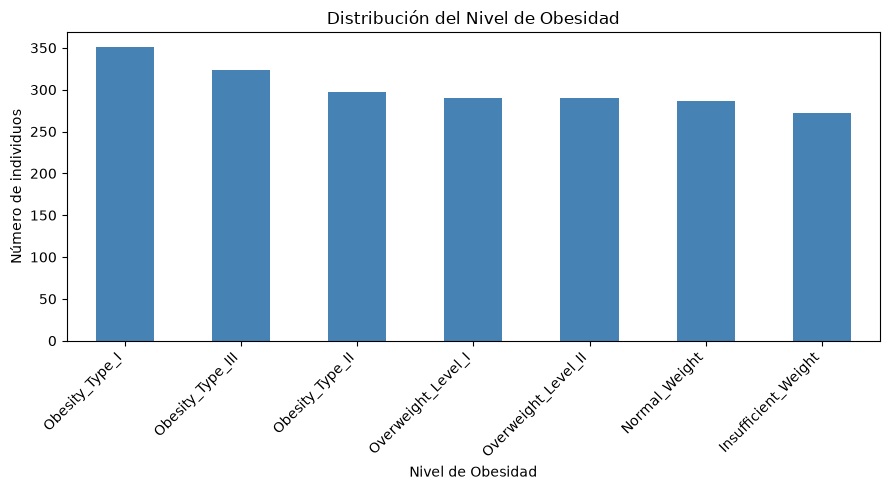

In [4]:

plt.figure(figsize=(9, 5))
df['NivelDeObesidad'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución del Nivel de Obesidad')
plt.xlabel('Nivel de Obesidad')
plt.ylabel('Número de individuos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretación:** las siete categorías presentan frecuencias similares, por lo que la variable de salida está balanceada.

## 4. Análisis gráfico enfocado en una subpoblación

Se selecciona la subpoblación **femenina** para explorar la relación entre "NivelDeObesidad"
(variable de salida) y "Peso" (variable cuantitativa), mediante un diagrama de caja.

<Figure size 1000x500 with 0 Axes>

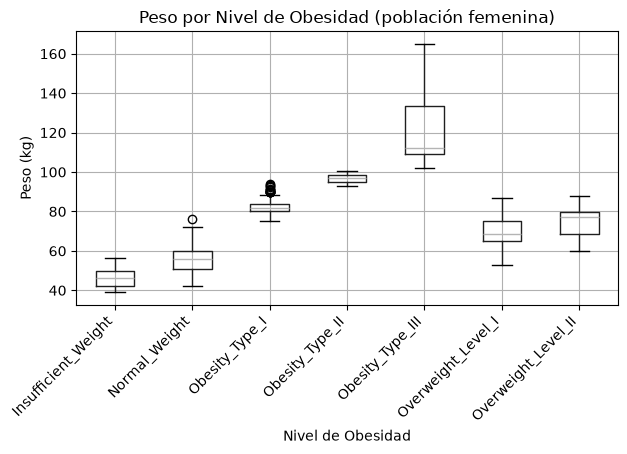

In [ ]:
df_f = df[df['Sexo'] == 'Male']

plt.figure(figsize=(10, 5))
df_f.boxplot(column='Peso', by='NivelDeObesidad',
             positions=range(1, 8))
plt.xticks(range(1, 8) , rotation=45, ha='right')
plt.title('Peso por Nivel de Obesidad (población masculina)')
plt.suptitle('')
plt.xlabel('Nivel de Obesidad')
plt.ylabel('Peso (kg)')
plt.tight_layout()
plt.show()

**Interpretación:** en la población masculina se observa una tendencia clara y creciente del
peso conforme aumenta el nivel de obesidad, desde "Insufficient_Weight" hasta "Obesity_Type_III".
La dispersión es relativamente reducida dentro de cada categoría, lo que indica que el peso es un buen discriminador entre niveles de obesidad. Se observan diferencias con las categorías intermedias, pero el patrón general confirma que el peso está relacionado con el nivel de obesidad que se calcula a partir del IMC.

## Conclusiones

El conjunto de datos analizado presenta una estructura completa y variables tanto cuantitativas como cualitativas relevantes para el estudio de la obesidad. La variable "NivelDeObesidad", seleccionada como variable de salida, muestra una distribución balanceada entre sus siete categorías. El análisis gráfico en la subpoblación masculina confirmó una relación clara y consistente entre el peso y el nivel de obesidad, en línea con lo esperado dado que este último se deriva del IMC. Estos hallazgos responden al objetivo general del reporte y construyen una base sólida para un análisis de inferencia más profundo para el futuro. 
*El codigo realizado para las graficas fue elaborado con apoyo de Claude AI*